In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snsMM

df = pd.read_csv("smartcart_customers.csv")

df.head()

In [137]:
df.shape

(2240, 22)

In [138]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [139]:
#handle data preprocessing
#1.handle missing values

In [140]:
df["Income"]=df["Income"].fillna(df["Income"].median())
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


Feature engineering

In [141]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [142]:
#age
df["Age"]=2026-df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [143]:
#customer joining date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["customer_Tenure_days"]=(reference_date-df["Dt_Customer"]).dt.days

In [144]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [145]:
#spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [146]:
#Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [147]:
#education
df["Education"].value_counts()

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})
#undergraduate,graduate,postgradute

In [148]:
df["Education"]

0           Graduate
1           Graduate
2           Graduate
3           Graduate
4       Postgraduate
            ...     
2235        Graduate
2236    Postgraduate
2237        Graduate
2238    Postgraduate
2239    Postgraduate
Name: Education, Length: 2240, dtype: object

In [149]:
#Marital state
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "Widow":"Alone"
    
})

In [150]:
df["Living_With"]

0         Alone
1         Alone
2       Partner
3       Partner
4       Partner
         ...   
2235    Partner
2236    Partner
2237      Alone
2238    Partner
2239    Partner
Name: Living_With, Length: 2240, dtype: object

In [151]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_drop=cols+spending_cols

df_cleaned=df.drop(columns=cols_drop)

In [152]:
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


In [153]:
#outliers
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]

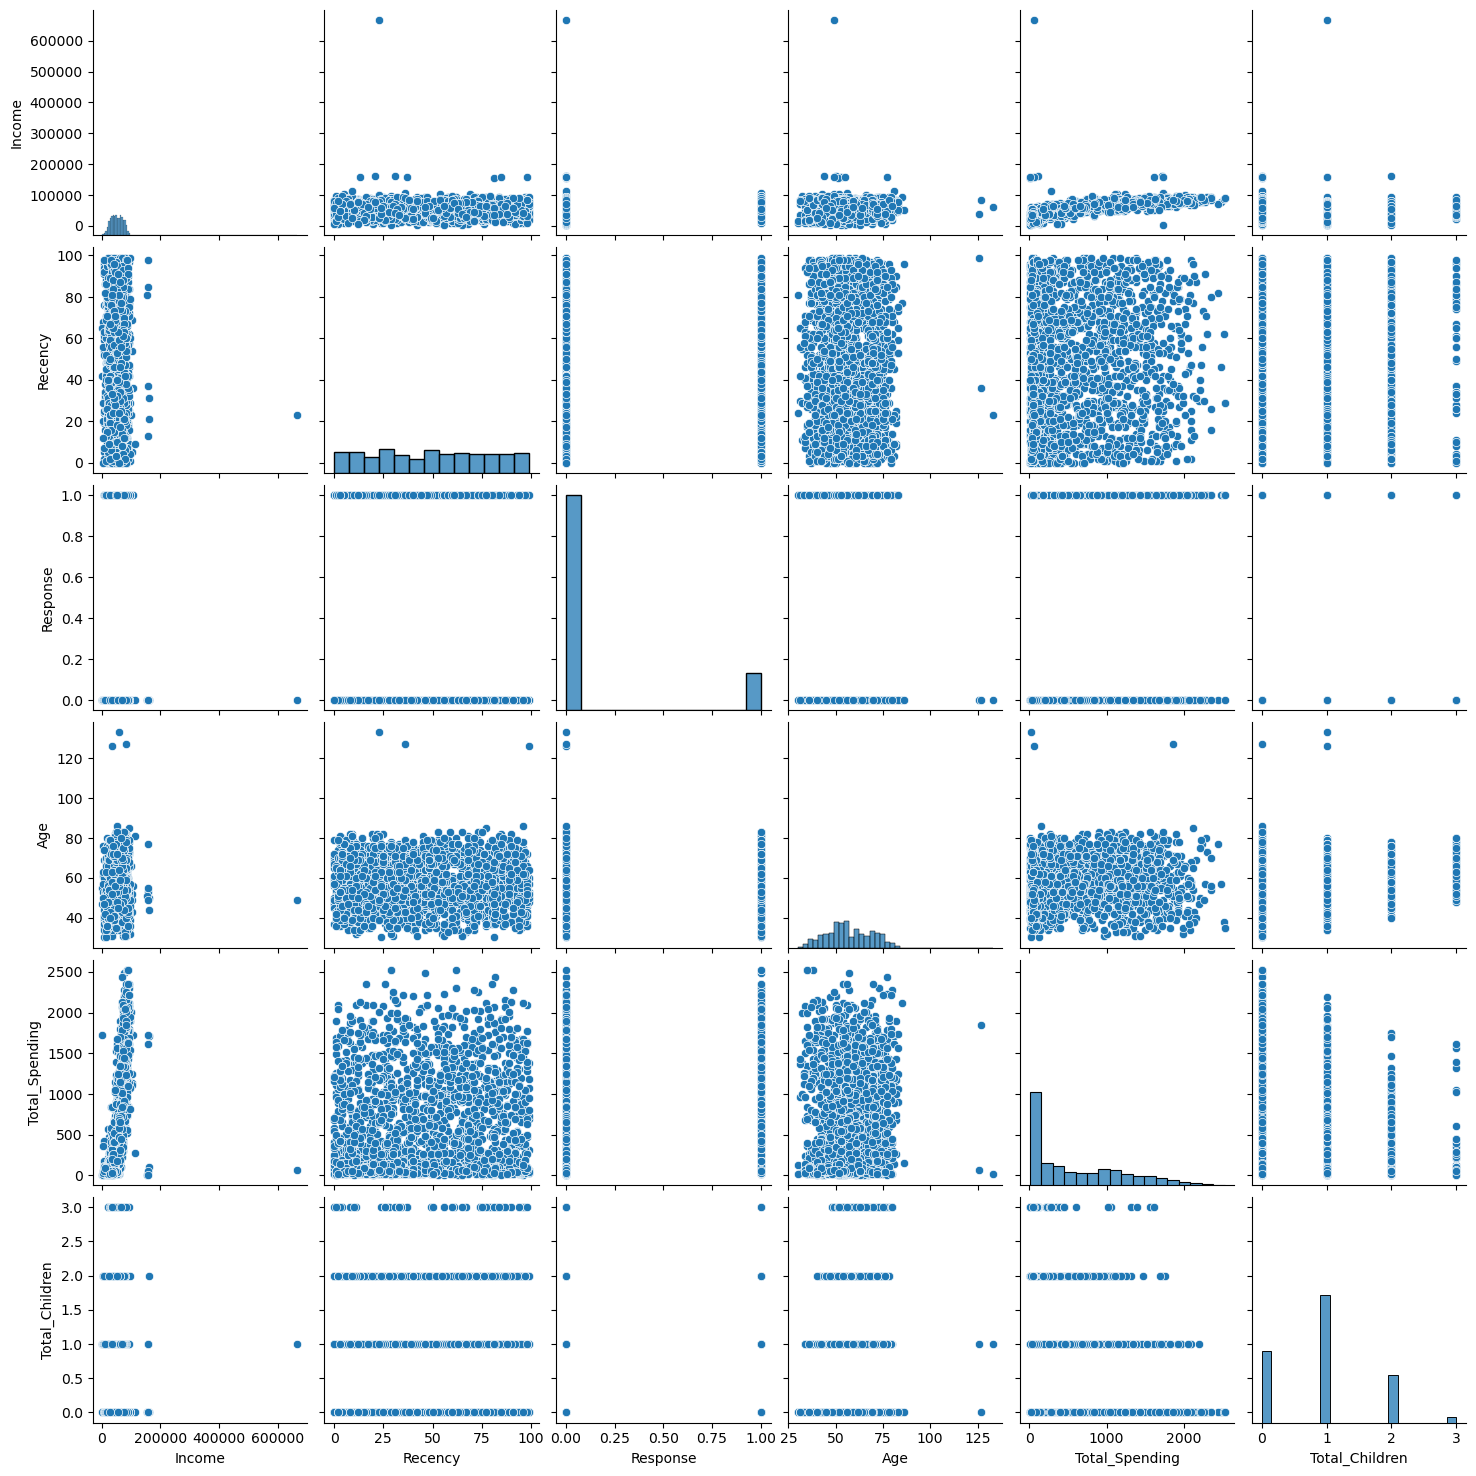

In [154]:
sns.pairplot(df_cleaned[cols])

In [155]:
#remove the outliers
print("data size with outliers",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]

data size with outliers 2240


In [156]:
print("data without outliers",len(df_cleaned))

data without outliers 2236


<Axes: >

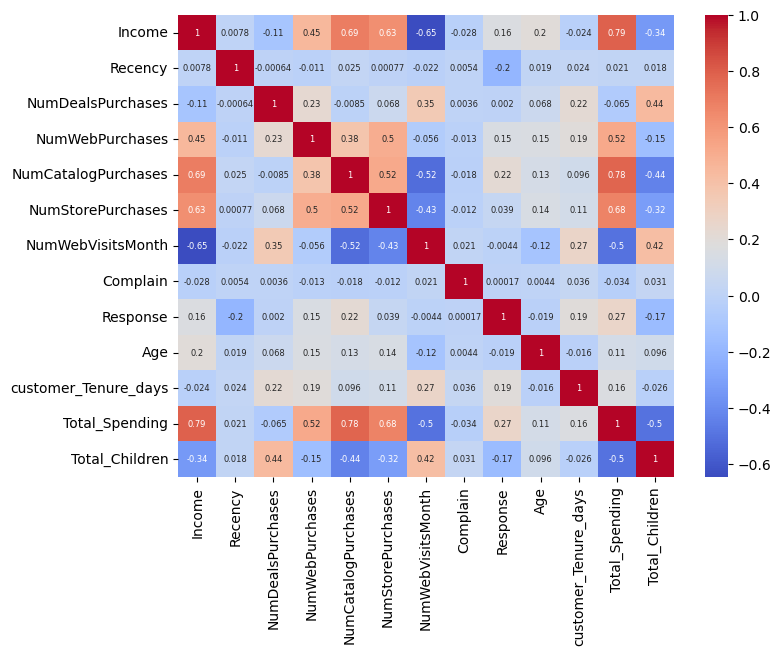

In [157]:
#Heatmap
corr=df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [158]:
#encoding
from sklearn.preprocessing import OneHotEncoder

In [159]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [ ]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [161]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Living_With_YOLO
0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0


In [162]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [163]:
#scalling
from sklearn.preprocessing import StandardScaler
X=df_encoded

In [164]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [165]:
#visualize
X_scaled.shape

(2236, 19)

In [166]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

C:\Users\Rahul shakya\anaconda3\Lib\site-packages\matplotlib\collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


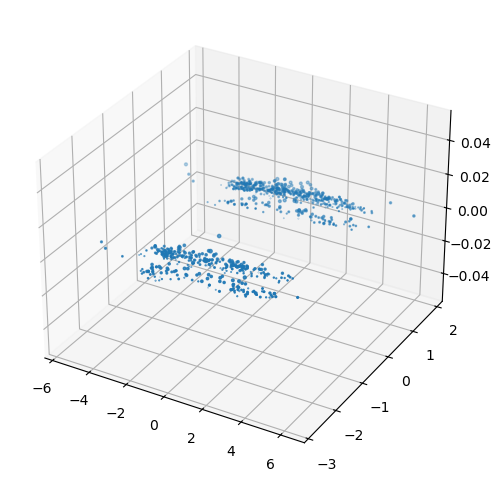

In [167]:

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

In [168]:
#analyze k value
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [169]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [170]:
print("best K = ",optimal_k)

best K =  3


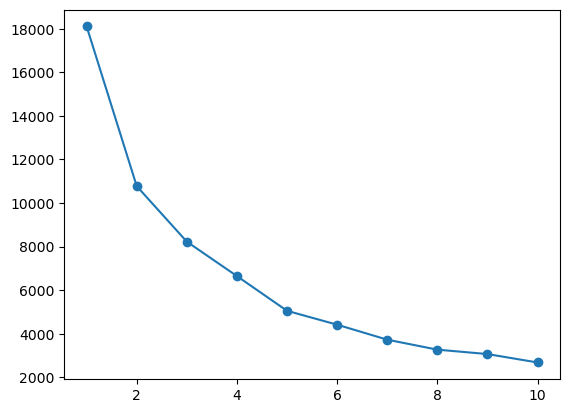

In [171]:
#plot
plt.plot(range(1,11),wcss,marker="o")

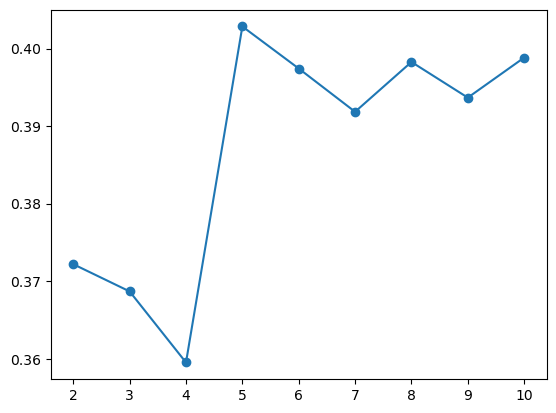

In [172]:
#silhoute score
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

    #plot
plt.plot(range(2,11),scores,marker="o")

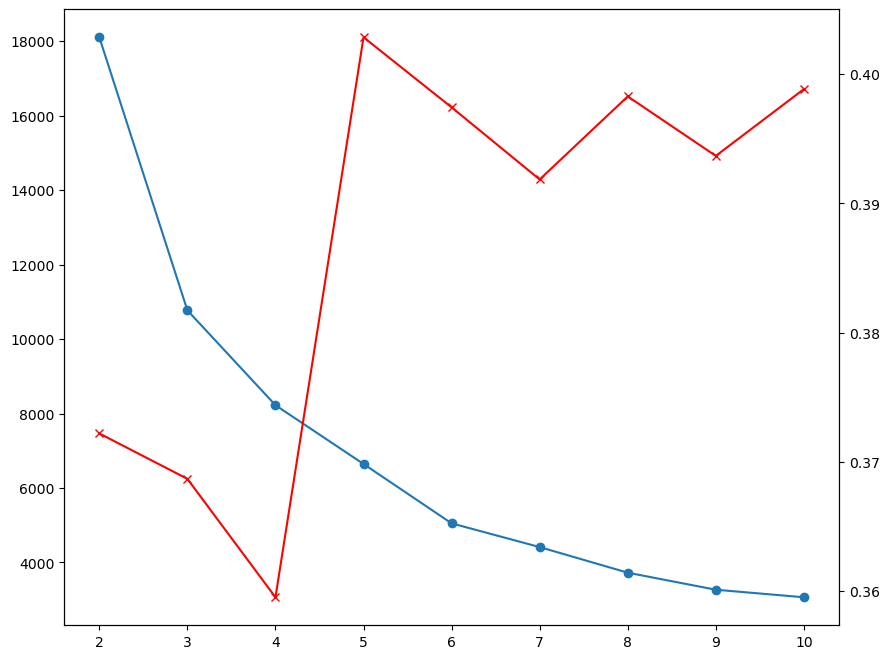

In [173]:
#combined plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))

ax1.plot(k_range,wcss[:len(k_range)],marker="o")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red")

In [174]:
#clustring
kmeans=KMeans(n_clusters=4,random_state=42)
labels=kmeans.fit_predict(X_pca)

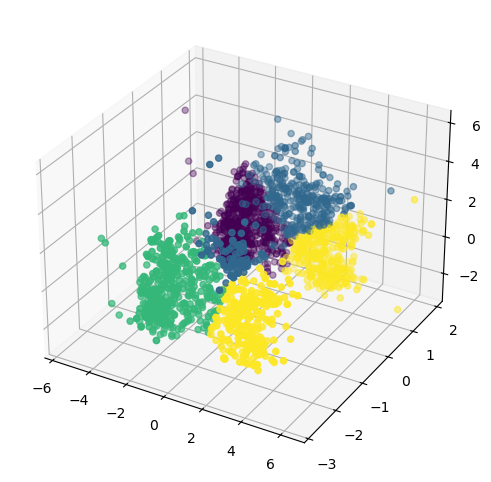

In [175]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

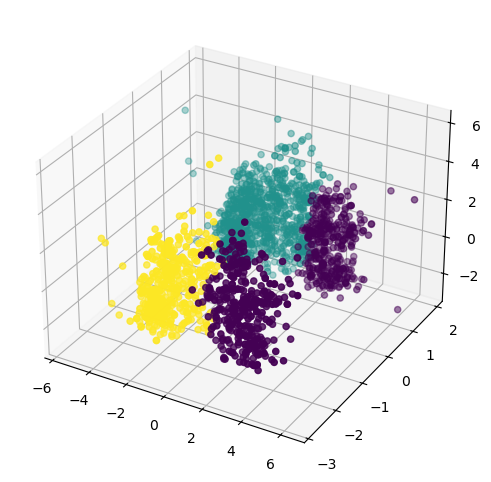

In [183]:
#agglomerative clustring
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3,linkage="ward")

labels = model.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)  

In [189]:
#characterization of clustors
df_cleaned["cluster"]=labels


In [190]:
 df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_Spending,Total_Children,Living_With,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,1
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,1


C:\Users\Rahul shakya\AppData\Local\Temp\ipykernel_28856\1313472148.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Rahul shakya\AppData\Local\Temp\ipykernel_28856\1313472148.py:4: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(


<Axes: xlabel='cluster', ylabel='count'>

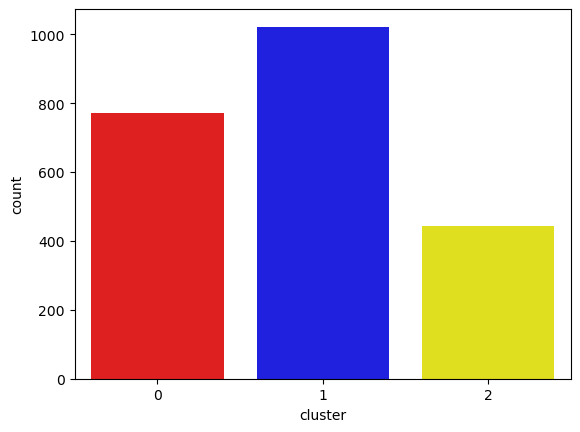

In [193]:
pal=["red","blue","yellow","green"]
pal = ["red","blue","yellow","green"]

sns.countplot(
    x = df_cleaned["cluster"],
    palette = pal
)

C:\Users\Rahul shakya\AppData\Local\Temp\ipykernel_28856\2955608102.py:3: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=pal)


<Axes: xlabel='Total_Spending', ylabel='Income'>

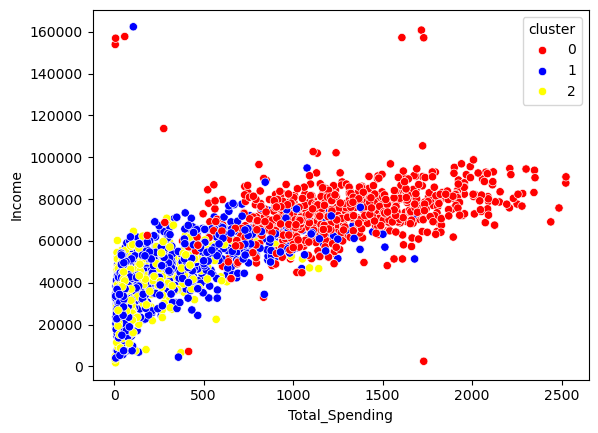

In [195]:
#income and spending patterns

sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=pal)

In [196]:
#clustor summary
cluster_summary = df_cleaned.groupby("cluster").mean(numeric_only=True)
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        73224.368523  49.345855           1.762953         5.716321   
1        42240.215264  49.280822           2.658513         3.445205   
2        37256.408371  48.334842           2.540724         2.728507   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   5.580311           8.584197           3.431347  0.005181   
1                   1.247554           4.607632           6.208415  0.010763   
2                   0.841629           3.671946           6.558824  0.011312   

         Response        Age  customer_Tenure_days  Total_Spending  \
cluster                                                              
0        0.246114  59.265544            371.225389     1278.617876   
1        0.081213  56.228963

In [199]:
import joblib
joblib.dump(model, 'clustering_model.pkl')

print("congratulation")

Mubarak ho! Model '.pkl' file mein save ho gaya hai.
